<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/8_6_Exercise1_SVM_Quadratic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8.6 Exercise 1 — Generate a Random Dataset Following a Quadratic Distribution and Classify with SVM

**Task:** Generate a random dataset whose class boundary follows a **quadratic** relationship, then use a **Support Vector Machine (SVM)** to classify it.

A linear SVM cannot separate classes that are divided by a curved (quadratic) boundary. This exercise demonstrates why, and shows how a **kernel SVM** (polynomial or RBF kernel) can successfully learn a non-linear, quadratic decision boundary — the essence of the "kernel trick."

## Dataset

This dataset is **synthetically generated** directly in this notebook: we draw random points `(x1, x2)` and label them based on whether they fall above or below the parabola `x2 = x1^2` (plus Gaussian noise). This is a standard, well-known synthetic pattern used to demonstrate non-linear SVMs (similar to scikit-learn's `make_moons` / `make_circles` style toy datasets, but built here to explicitly follow a **quadratic** curve).

Reference / similar public examples of non-linear synthetic datasets used for SVM kernel demos:
- **scikit-learn's built-in non-linear datasets:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html
- **scikit-learn's built-in non-linear datasets:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

No external download is required — the dataset is generated with NumPy below and is fully reproducible via the fixed random seed.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
%matplotlib inline

## 2. Generate a Random Dataset Following a Quadratic Distribution

We sample `x1` uniformly, then define the quadratic boundary `x2 = x1^2`. Points **above** the curve are class 1, points **below** are class 0. We add Gaussian noise to both the coordinates and near the boundary so the classes are not perfectly separable (more realistic).

In [2]:
n_samples = 400

x1 = np.random.uniform(-3, 3, n_samples)
x2 = np.random.uniform(-2, 10, n_samples)

# Quadratic boundary: x2 = x1^2
boundary = x1 ** 2

# Label: 1 if point lies above the parabola, 0 if below
noise = np.random.normal(0, 1.0, n_samples)   # noise to blur the boundary a bit
y = (x2 > (boundary + noise)).astype(int)

X = np.column_stack([x1, x2])

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class balance: {np.bincount(y)}")

X shape: (400, 2), y shape: (400,)
Class balance: [181 219]


## 3. Visualize the Raw Data

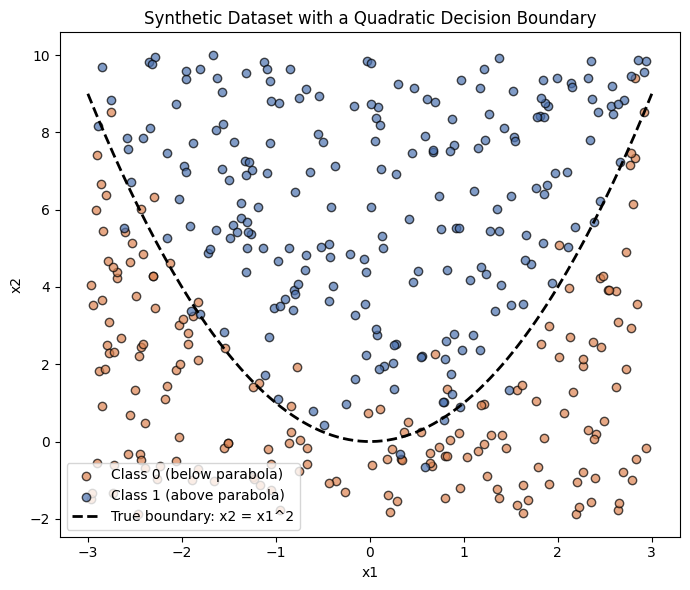

In [3]:
plt.figure(figsize=(7, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='#DD8452', label='Class 0 (below parabola)', edgecolor='k', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#4C72B0', label='Class 1 (above parabola)', edgecolor='k', alpha=0.7)

x1_line = np.linspace(-3, 3, 200)
plt.plot(x1_line, x1_line ** 2, 'k--', linewidth=2, label='True boundary: x2 = x1^2')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Synthetic Dataset with a Quadratic Decision Boundary')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Train/Test Split and Scaling

SVMs are sensitive to feature scale, so we standardize the features.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 300, Testing samples: 100


## 5. Baseline: Linear SVM (Expected to Struggle)

A linear kernel can only draw a straight-line boundary, so it should perform noticeably worse on this quadratic pattern.

In [5]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_linear):.2%}")

Linear SVM Accuracy: 79.00%


## 6. Kernel SVM: Polynomial (degree=2) — Matches the Quadratic Shape

In [6]:
svm_poly = SVC(kernel='poly', degree=2, C=1.0, coef0=1.0)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)
print(f"Polynomial (degree=2) SVM Accuracy: {accuracy_score(y_test, y_pred_poly):.2%}")

Polynomial (degree=2) SVM Accuracy: 92.00%


## 7. Kernel SVM: RBF (Also Handles Non-linear Boundaries Well)

In [7]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
print(f"RBF SVM Accuracy: {accuracy_score(y_test, y_pred_rbf):.2%}")

RBF SVM Accuracy: 91.00%


## 8. Visualize Decision Boundaries: Linear vs. Polynomial vs. RBF

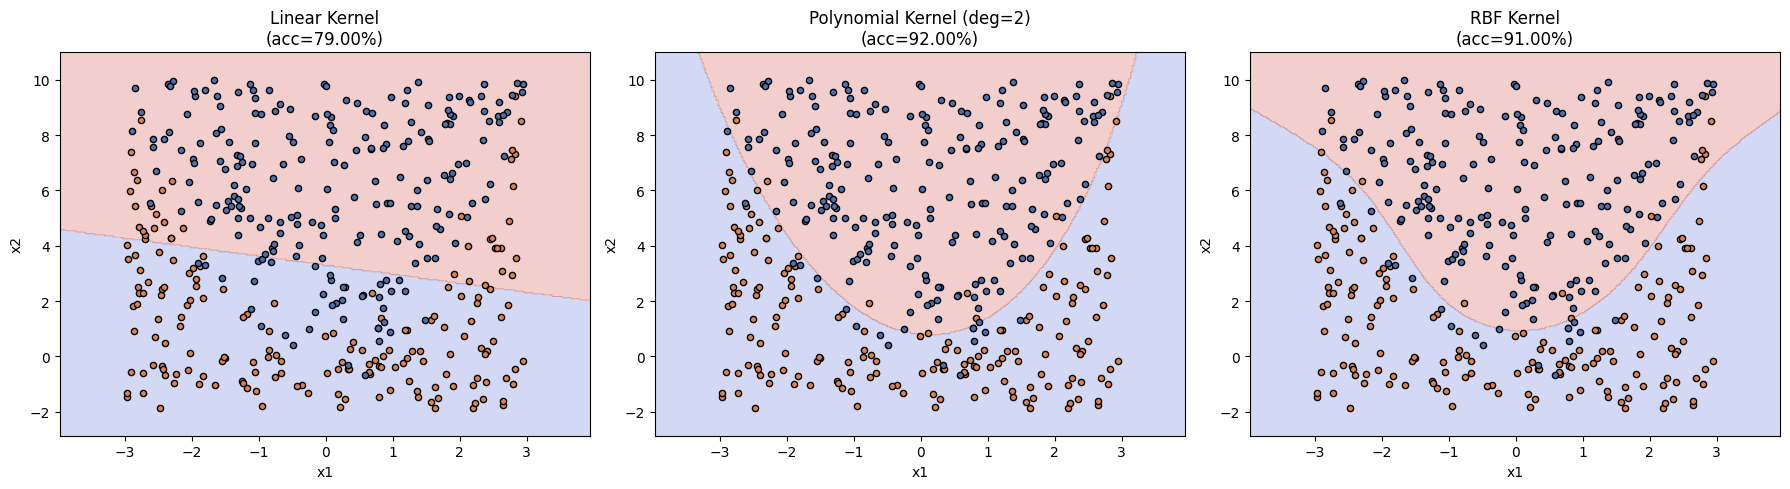

In [8]:
def plot_decision_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z = model.predict(grid_scaled).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#DD8452', edgecolor='k', s=20, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#4C72B0', edgecolor='k', s=20, label='Class 1')
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(axes[0], svm_linear, X, y, f"Linear Kernel\n(acc={accuracy_score(y_test, y_pred_linear):.2%})")
plot_decision_boundary(axes[1], svm_poly, X, y, f"Polynomial Kernel (deg=2)\n(acc={accuracy_score(y_test, y_pred_poly):.2%})")
plot_decision_boundary(axes[2], svm_rbf, X, y, f"RBF Kernel\n(acc={accuracy_score(y_test, y_pred_rbf):.2%})")
plt.tight_layout()
plt.show()

## 9. Detailed Evaluation of the Best Model (Polynomial Kernel)

In [9]:
print("Classification Report (Polynomial Kernel SVM):")
print(classification_report(y_test, y_pred_poly))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_poly))

Classification Report (Polynomial Kernel SVM):
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        45
           1       0.96      0.89      0.92        55

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100

Confusion Matrix:
[[43  2]
 [ 6 49]]


## Conclusion

- We generated a synthetic dataset whose classes are separated by a **quadratic curve** (`x2 = x1^2`).
- A **linear SVM** cannot capture this curved boundary well and shows lower accuracy.
- **Kernel SVMs** (polynomial degree-2 and RBF) successfully model the non-linear, quadratic-shaped boundary by implicitly mapping the data into a higher-dimensional space (the "kernel trick"), achieving much higher accuracy.
- This mirrors real-world use cases where relationships between features and classes are non-linear and a plain linear classifier would underfit.